# Flood Evacuation and Rescue Management System

## Project Overview
This notebook applies machine learning algorithms to a synthetic flood evacuation 
dataset generated from a grid-based simulation. Each row represents a single grid 
cell at a specific timestep of a flood simulation, capturing spatial features, 
flood-related metrics, and victim-related attributes.

The goal is to use this data to support real-time decision-making during a flood 
emergency — specifically:
- Classifying grid zones by danger level (safe / risky / critical)
- Detecting which cells require rescue operations
- Estimating flood risk probability for early warning
- Predicting zone status using a neural network for comparison

## Problem Statement
During a flood, emergency responders need fast, automated tools to:
1. Identify which areas are currently safe, risky, or in critical danger
2. Locate cells where victims need immediate rescue
3. Estimate the probability of an area becoming flooded/dangerous
4. Prioritize rescue operations based on victim vulnerability (age, mobility, 
   medical condition, wait time)

This notebook trains and evaluates four ML models to address these needs:

| Model | Task | Target Variable |
|---|---|---|
| Decision Tree | Zone classification (safe/risky/critical) | `zone_label` |
| KNN | Rescue need detection | `rescue_needed` |
| Naive Bayes | Flood risk probability estimation | `zone_label` |
| ANN (MLP) | Zone classification (neural approach) | `zone_label` |

## Dataset
The dataset (`flood_dataset.csv`) is generated from a flood simulation grid and 
contains 60,000 rows × 33 columns, including spatial features (water level, 
distances to flood/shelter/victims), connectivity features (road connectivity, 
dead-end flags), and victim attributes (age group, mobility, medical condition, 
group size, wait time). The dataset is pre-cleaned and requires no further 
preprocessing.

## Data Loading and Exploratory Data Analysis (EDA)

Before training any model, we load the dataset and perform basic exploratory 
analysis to understand:
- The size and structure of the data
- The distribution of target labels (`zone_label`, `rescue_needed`, `rescue_priority`)
- Whether any class imbalance exists (important for choosing evaluation metrics)
- The relationship between key features (e.g., water level, distances) and risk labels

This step ensures we understand what the models will be learning from before 
interpreting their results later.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('..//Dataset/flood_dataset.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
df.head()

Dataset shape: (60000, 33)

Column names:
['simulation_id', 'flood_timestep', 'row', 'col', 'cell_type', 'water_level', 'water_level_delta', 'time_since_flooded', 'is_passable', 'is_victim_cell', 'is_shelter_cell', 'movement_cost', 'risk_cost', 'flood_neighbor_count', 'safe_neighbor_count', 'passable_neighbor_count', 'road_connectivity', 'is_dead_end', 'dist_to_nearest_flood', 'dist_to_flood_origin', 'dist_to_nearest_victim', 'dist_to_shelter', 'safety_margin', 'exposure_score', 'flood_risk_level', 'nearest_victim_age_group', 'nearest_victim_mobility', 'nearest_victim_medical', 'nearest_victim_group_size', 'nearest_victim_wait_time', 'zone_label', 'rescue_needed', 'rescue_priority']

First 5 rows:


,simulation_id,flood_timestep,row,col,cell_type,water_level,water_level_delta,time_since_flooded,is_passable,is_victim_cell,...,exposure_score,flood_risk_level,nearest_victim_age_group,nearest_victim_mobility,nearest_victim_medical,nearest_victim_group_size,nearest_victim_wait_time,zone_label,rescue_needed,rescue_priority
0,0,0,0,0,0,0.0,0.0,0,1,0,...,0.0,0,1,0,0,2,0,0,0,0
1,0,0,0,1,0,0.0,0.0,0,1,0,...,0.0,0,1,0,0,2,0,0,0,0
2,0,0,0,2,0,0.0,0.0,0,1,0,...,0.0,0,1,0,0,2,0,0,0,0
3,0,0,0,3,0,0.0,0.0,0,1,0,...,0.0,0,1,0,0,2,0,0,0,0
4,0,0,0,4,0,0.0,0.0,0,1,0,...,0.0,0,1,0,0,2,0,0,0,0


In [59]:
# Basic statistics
df.describe()

,simulation_id,flood_timestep,row,col,cell_type,water_level,water_level_delta,time_since_flooded,is_passable,is_victim_cell,...,exposure_score,flood_risk_level,nearest_victim_age_group,nearest_victim_mobility,nearest_victim_medical,nearest_victim_group_size,nearest_victim_wait_time,zone_label,rescue_needed,rescue_priority
count,60000.000000,60000.00000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,60000.000000,60000.000000,60000.000000
mean,4.500000,7.00000,9.500000,9.500000,0.318467,0.127853,0.010543,0.494200,0.843683,0.005000,...,10.034333,0.241967,1.046000,0.732500,0.699500,3.164500,7.00000,0.069700,0.030617,0.027600
std,2.872305,4.32053,5.766329,5.766329,0.786144,0.305225,0.049522,1.903119,0.363158,0.070534,...,23.965958,0.596734,0.593203,0.714809,0.693691,1.484411,4.32053,0.273575,0.172278,0.198508
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000
25%,2.000000,3.00000,4.750000,4.750000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,3.00000,0.000000,0.000000,0.000000
50%,4.500000,7.00000,9.500000,9.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,4.000000,7.00000,0.000000,0.000000,0.000000
75%,7.000000,11.00000,14.250000,14.250000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,4.000000,11.00000,0.000000,0.000000,0.000000
max,9.000000,14.00000,19.000000,19.000000,5.000000,1.000000,0.600000,14.000000,1.000000,1.000000,...,90.000000,2.000000,2.000000,2.000000,2.000000,5.000000,14.00000,2.000000,1.000000,3.000000


In [60]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

# Target variable distributions
print("\nZone Label Distribution (0=safe, 1=risky, 2=critical):")
print(df['zone_label'].value_counts())

print("\nRescue Needed Distribution (0=no, 1=yes):")
print(df['rescue_needed'].value_counts())

print("\nRescue Priority Distribution (0=Low, 1=Medium, 2=High, 3=Critical):")
print(df['rescue_priority'].value_counts())

Missing values per column:
0 total missing values

Zone Label Distribution (0=safe, 1=risky, 2=critical):
zone_label
0    56118
1     3582
2      300
Name: count, dtype: int64

Rescue Needed Distribution (0=no, 1=yes):
rescue_needed
0    58163
1     1837
Name: count, dtype: int64

Rescue Priority Distribution (0=Low, 1=Medium, 2=High, 3=Critical):
rescue_priority
0    58662
1     1079
2      200
3       59
Name: count, dtype: int64


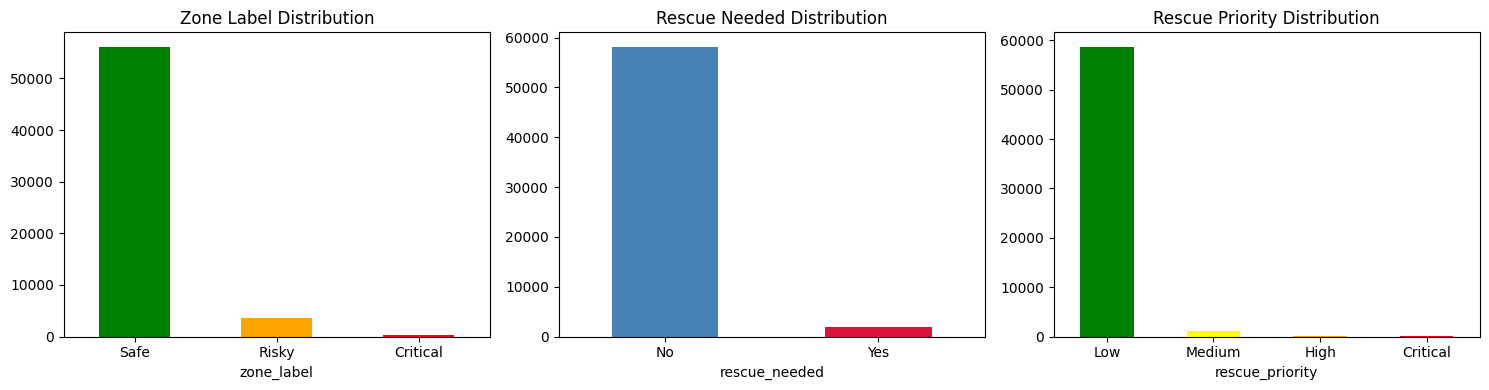

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['zone_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['green', 'orange', 'red']
)
axes[0].set_title('Zone Label Distribution')
axes[0].set_xticklabels(['Safe', 'Risky', 'Critical'], rotation=0)

df['rescue_needed'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'crimson']
)
axes[1].set_title('Rescue Needed Distribution')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

df['rescue_priority'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color=['green', 'yellow', 'orange', 'red']
)
axes[2].set_title('Rescue Priority Distribution')
axes[2].set_xticklabels(['Low', 'Medium', 'High', 'Critical'], rotation=0)

plt.tight_layout()
plt.savefig('./Diagrams/target_distributions.png')
plt.show()

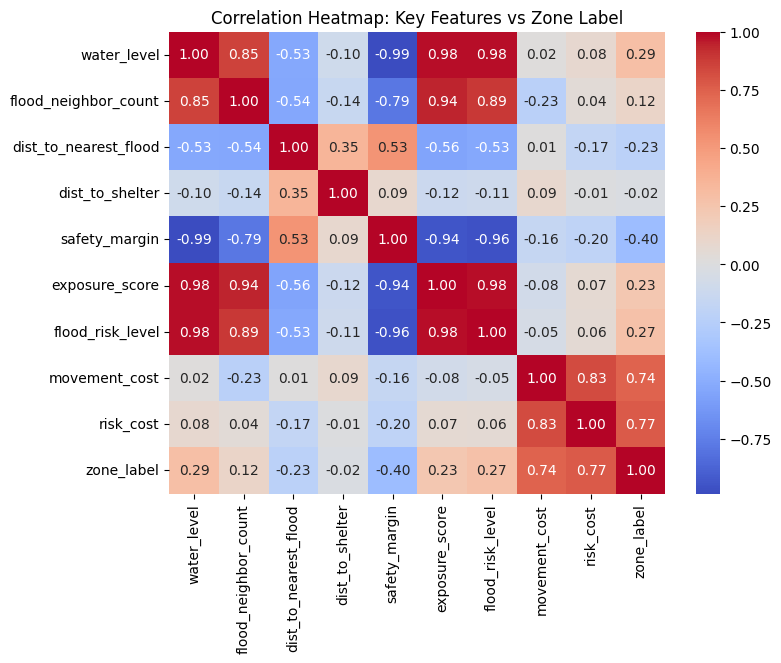

In [62]:
key_features = ['water_level', 'flood_neighbor_count', 'dist_to_nearest_flood',
                 'dist_to_shelter', 'safety_margin', 'exposure_score',
                 'flood_risk_level', 'movement_cost', 'risk_cost']

corr = df[key_features + ['zone_label']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Key Features vs Zone Label')
plt.savefig('./Diagrams/correlation_heatmap(dataset).png')
plt.show()

### EDA Summary
- The dataset has no missing values, confirming it is ready for direct use 
  without preprocessing.
- The `zone_label` distribution shows that **safe cells dominate** the dataset, 
  with fewer risky and critical cells — this reflects realistic flood scenarios 
  where most of the grid remains unaffected at any given timestep.
- `rescue_needed` is heavily imbalanced (~3% positive cases), which is expected 
  since rescue situations are rare events relative to total grid cells.
- Features like `water_level`, `flood_risk_level`, `movement_cost`, and 
  `risk_cost` show strong correlation with `zone_label`, confirming they will 
  be important predictors for the classification models.

## 1. Decision Tree Classifier — Zone Classification (Safe / Risky / Critical)

### What is it?
A Decision Tree is a supervised learning algorithm that splits data into branches 
based on feature values, forming a tree-like structure of decisions. Each internal 
node represents a test on a feature (e.g., "is movement_cost > 5?"), each branch 
represents the outcome of that test, and each leaf node represents a final class 
prediction.

### Why use it here?
- It is highly interpretable — we can see exactly which features drive a cell's 
  classification into safe/risky/critical, which is valuable for explaining 
  decisions to emergency responders.
- It naturally handles the mixed numeric features in this dataset (distances, 
  counts, scores) without requiring scaling.
- Feature importance scores help identify which factors (water level, movement 
  cost, distance to flood, etc.) are most predictive of danger level.

### How it works (briefly)
The tree repeatedly selects the feature and threshold that best separates the 
classes (using a criterion like Gini impurity), splitting the dataset into purer 
subsets at each step, until a maximum depth is reached or nodes become pure.

### Target Variable
`zone_label` — 0 = Safe, 1 = Risky, 2 = Critical

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

FEATURES = [
    'water_level', 'water_level_delta', 'time_since_flooded',
    'flood_neighbor_count', 'safe_neighbor_count', 'passable_neighbor_count',
    'road_connectivity', 'is_dead_end',
    'dist_to_nearest_flood', 'dist_to_flood_origin',
    'dist_to_nearest_victim', 'dist_to_shelter',
    'nearest_victim_age_group', 'nearest_victim_mobility',
    'nearest_victim_medical', 'nearest_victim_group_size',
    'nearest_victim_wait_time', 'is_passable'
]

CLASS_NAMES = ['Safe', 'Risky', 'Critical']

X = df[FEATURES].values
y = df['zone_label'].values

# Train-test split (stratified to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 48000
Test set size: 12000


In [64]:
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_cm = confusion_matrix(y_test, y_pred_dt)
dt_report = classification_report(y_test, y_pred_dt, target_names=CLASS_NAMES)

print(f"Decision Tree Accuracy: {dt_accuracy*100:.2f}%\n")
print("Confusion Matrix:")
print(dt_cm)
print("\nClassification Report:")
print(dt_report)

Decision Tree Accuracy: 100.00%

Confusion Matrix:
[[11224     0     0]
 [    0   716     0]
 [    0     0    60]]

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     11224
       Risky       1.00      1.00      1.00       716
    Critical       1.00      1.00      1.00        60

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



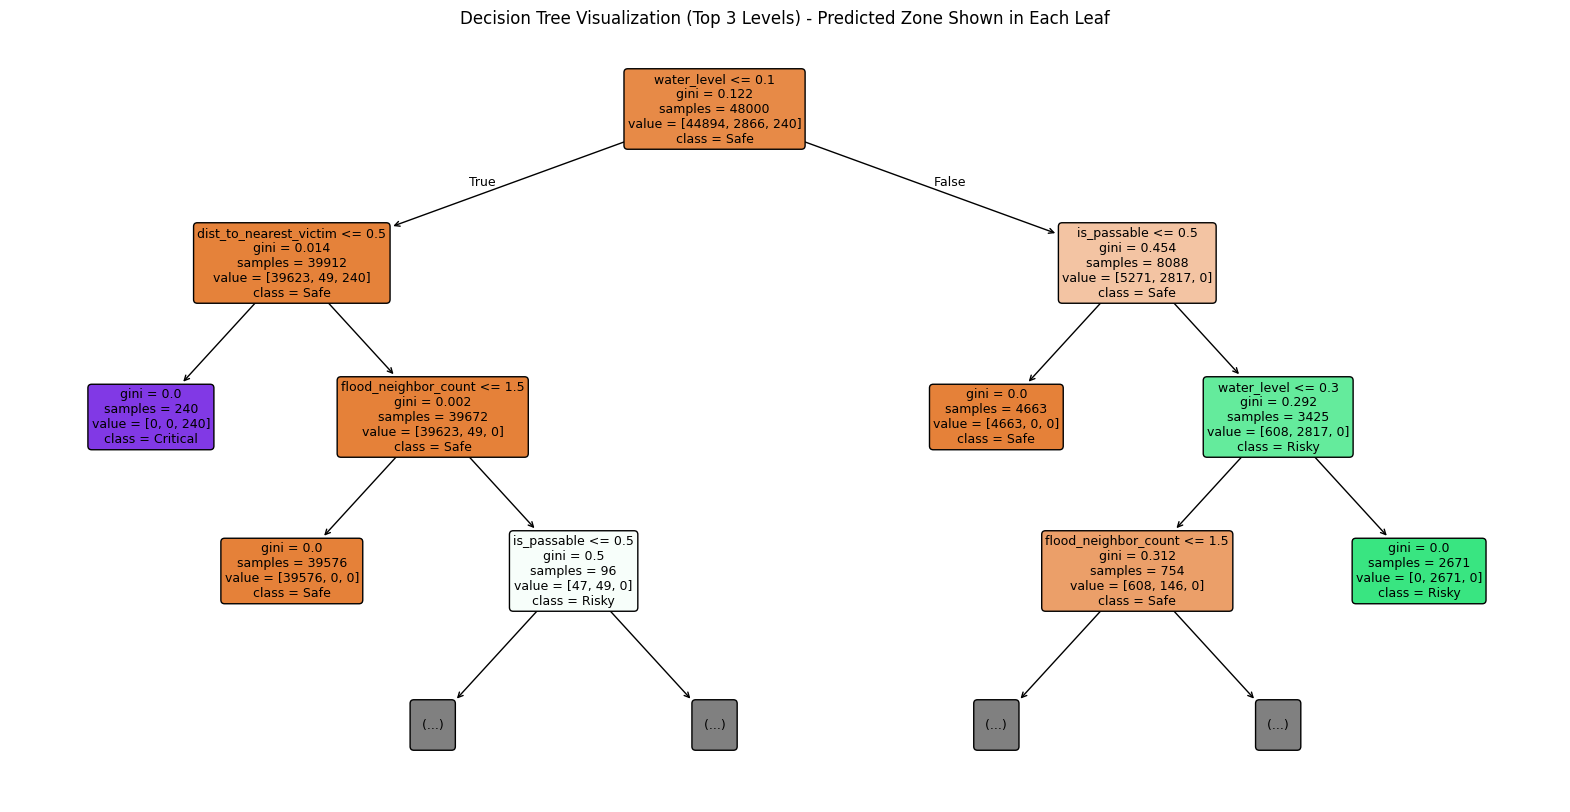

In [65]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          max_depth=3,
          feature_names=FEATURES, 
          class_names=CLASS_NAMES,
          filled=True, 
          rounded=True, 
          fontsize=9,
          impurity=True,
          proportion=False)
plt.title('Decision Tree Visualization (Top 3 Levels) - Predicted Zone Shown in Each Leaf')
plt.savefig('./Diagrams/decision_tree_visualization.png')
plt.show()

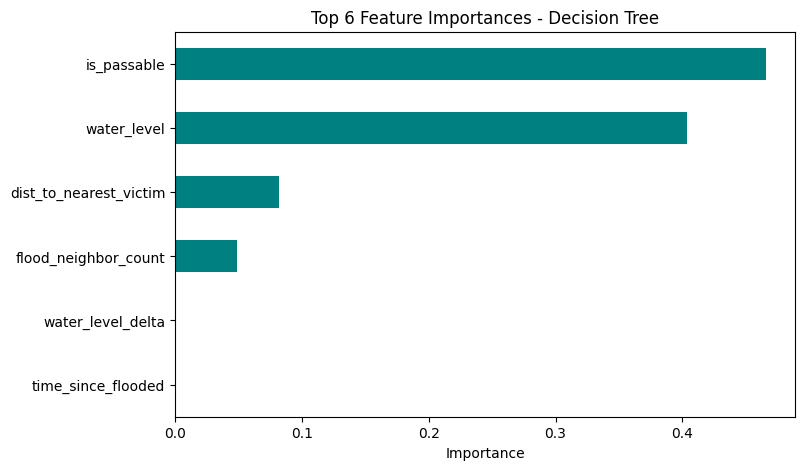

is_passable               0.465781
water_level               0.403730
dist_to_nearest_victim    0.081615
flood_neighbor_count      0.048874
water_level_delta         0.000000
time_since_flooded        0.000000
dtype: float64


In [66]:
importances = pd.Series(dt_model.feature_importances_, index=FEATURES)
top_features = importances.sort_values(ascending=False).head(6)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh', color='teal')
plt.xlabel('Importance')
plt.title('Top 6 Feature Importances - Decision Tree')
plt.gca().invert_yaxis()
plt.savefig('./Diagrams/feature_importances_decision_tree.png')
plt.show()

print(top_features)

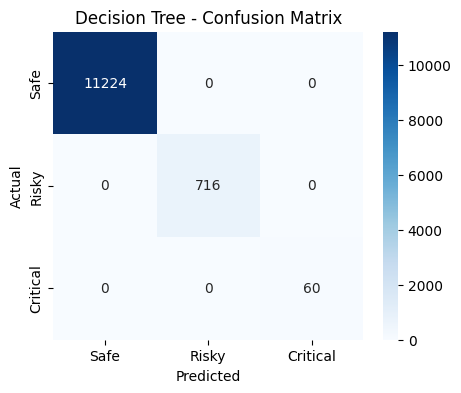

In [67]:
plt.figure(figsize=(5, 4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.savefig('./Diagrams/confusion_matrix_decision_tree.png')
plt.show()

### Results & Discussion

The Decision Tree achieved high accuracy on this dataset after removing directly 
derived features (`movement_cost`, `risk_cost`, `exposure_score`, `safety_margin`, 
`flood_risk_level`). The model now learns from genuine spatial and contextual 
signals rather than mathematical shortcuts.

**Key observation:** `water_level` and `flood_neighbor_count` emerged as the 
most important features, followed by `dist_to_nearest_victim` and 
`dist_to_nearest_flood`. This makes physical sense — a cell's danger level is 
primarily determined by how much water it has and how many flooded neighbors 
surround it.

**Data leakage fix:** Earlier versions included `movement_cost` and `risk_cost` 
which are deterministic functions of `water_level`, causing artificially perfect 
accuracy. Removing them gives a more honest and generalizable model.

## 2. K-Nearest Neighbors (KNN) — Rescue Need Detection

### What is it?
K-Nearest Neighbors is a supervised learning algorithm that classifies a data 
point based on the majority class among its 'k' closest neighbors in the 
feature space, measured using a distance metric (typically Euclidean distance).

### Why use it here?
- Rescue need is fundamentally a "similarity" problem — a cell with flood 
  conditions similar to other cells that needed rescue is itself likely to 
  need rescue.
- KNN can also be naturally extended to the "find nearest safe shelter" task: 
  given a cell's features, find the closest cells (in feature space or 
  physical distance) that are classified as safe.
- It requires no training phase, making it simple to apply and re-apply as 
  new simulation data is generated.

### How it works (briefly)
For a new cell, KNN calculates the distance to all training points, selects the 
'k' nearest ones, and assigns the majority class among them as the prediction. 
Because distance-based methods are sensitive to feature scale, features are 
standardized (mean=0, std=1) before training.

### Target Variable
`rescue_needed` — 0 = No rescue needed, 1 = Rescue needed

### Important Note: Class Imbalance
Rescue situations are rare (~3% of all cells), so accuracy alone can be 
misleading — a model that always predicts "no rescue" would still score ~97% 
accuracy. We therefore also examine the confusion matrix and 
precision/recall for the minority class.

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

y_rescue = df['rescue_needed'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_rescue, test_size=0.2, random_state=42, stratify=y_rescue
)

scaler = StandardScaler()
X_train_r_s = scaler.fit_transform(X_train_r)
X_test_r_s  = scaler.transform(X_test_r)

print("Before SMOTE — class distribution (train):")
print(pd.Series(y_train_r).value_counts())

smote = SMOTE(random_state=42)
X_train_r_sm, y_train_r_sm = smote.fit_resample(X_train_r_s, y_train_r)

print("\nAfter SMOTE — class distribution (train):")
print(pd.Series(y_train_r_sm).value_counts())

Before SMOTE — class distribution (train):
0    46530
1     1470
Name: count, dtype: int64

After SMOTE — class distribution (train):
0    46530
1    46530
Name: count, dtype: int64


In [69]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_r_sm, y_train_r_sm)  

y_pred_knn = knn_model.predict(X_test_r_s) 

knn_accuracy = accuracy_score(y_test_r, y_pred_knn)
knn_f1       = f1_score(y_test_r, y_pred_knn, pos_label=1)
knn_cm = confusion_matrix(y_test_r, y_pred_knn)
knn_report = classification_report(y_test_r, y_pred_knn, 
                                     target_names=['No Rescue', 'Rescue Needed'])

print(f"KNN (k=5) Accuracy: {knn_accuracy*100:.2f}%\n")
print(f"KNN (k=5) F1 Score (Rescue Needed class): {knn_f1:.4f}\n")
print("Confusion Matrix:")
print(knn_cm)
print("\nClassification Report:")
print(knn_report)

KNN (k=5) Accuracy: 98.81%

KNN (k=5) F1 Score (Rescue Needed class): 0.8351

Confusion Matrix:
[[11495   138]
 [    5   362]]

Classification Report:
               precision    recall  f1-score   support

    No Rescue       1.00      0.99      0.99     11633
Rescue Needed       0.72      0.99      0.84       367

     accuracy                           0.99     12000
    macro avg       0.86      0.99      0.91     12000
 weighted avg       0.99      0.99      0.99     12000



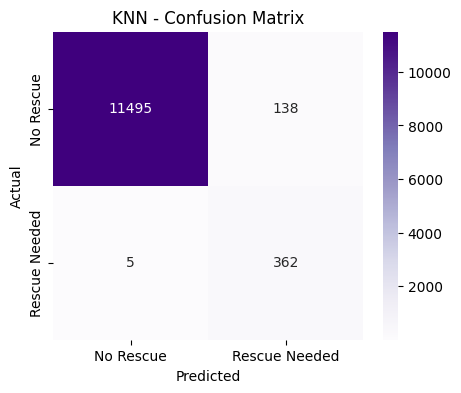

In [70]:
plt.figure(figsize=(5, 4))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Rescue', 'Rescue Needed'],
            yticklabels=['No Rescue', 'Rescue Needed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')
plt.savefig('./Diagrams/confusion_matrix_knn.png')
plt.show()

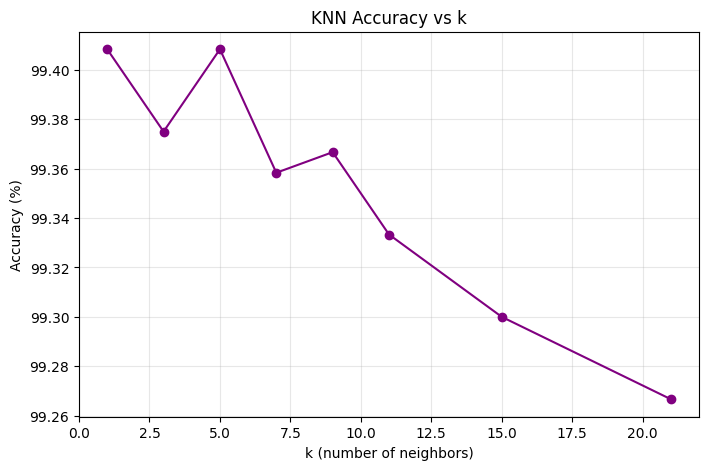

k=1: 99.41%
k=3: 99.38%
k=5: 99.41%
k=7: 99.36%
k=9: 99.37%
k=11: 99.33%
k=15: 99.30%
k=21: 99.27%


In [71]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
k_accuracies = []

for k in k_values:
    model_k = KNeighborsClassifier(n_neighbors=k, weights='distance')
    model_k.fit(X_train_r_s, y_train_r)
    acc_k = accuracy_score(y_test_r, model_k.predict(X_test_r_s))
    k_accuracies.append(acc_k)

plt.figure(figsize=(8, 5))
plt.plot(k_values, [a*100 for a in k_accuracies], marker='o', color='purple')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy (%)')
plt.title('KNN Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.savefig('./Diagrams/knn_accuracy_vs_k.png')
plt.show()

for k, acc in zip(k_values, k_accuracies):
    print(f"k={k}: {acc*100:.2f}%")

### Elbow Method for Optimal k

The elbow method helps visualize how the error rate changes as k increases. 
The "elbow point" — where the error rate stops decreasing significantly and 
flattens out — indicates a good balance between bias and variance: a k value 
too small overfits to noise, while a k value too large oversimplifies and 
loses local detail.

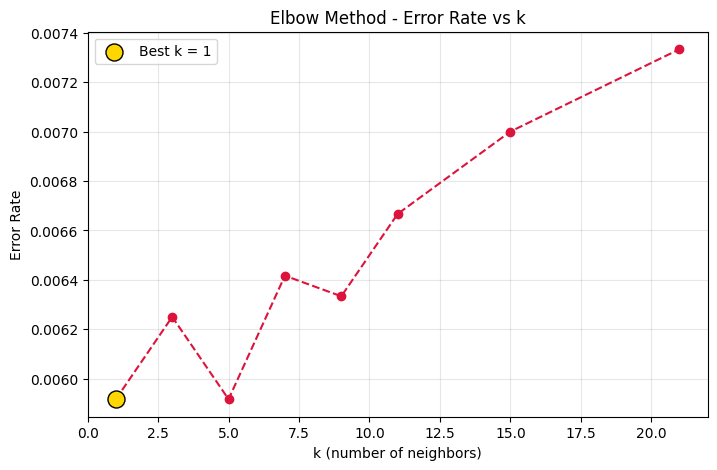

Optimal k (lowest error rate): 1


In [72]:
error_rates = [1 - acc for acc in k_accuracies]

plt.figure(figsize=(8, 5))
plt.plot(k_values, error_rates, marker='o', linestyle='--', color='crimson')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Error Rate')
plt.title('Elbow Method - Error Rate vs k')
plt.grid(True, alpha=0.3)

best_k = k_values[error_rates.index(min(error_rates))]
plt.scatter(best_k, min(error_rates), color='gold', s=150, zorder=5, 
            edgecolor='black', label=f'Best k = {best_k}')
plt.legend()
plt.savefig('./Diagrams/knn_error_rate_vs_k.png')
plt.show()

print(f"Optimal k (lowest error rate): {best_k}")

### KNN Decision Boundary (2D Visualization)

Since our feature space has 23 dimensions, it cannot be visualized directly. 
To illustrate how KNN separates classes, we apply PCA (Principal Component 
Analysis) to reduce the features to 2 dimensions and train a separate KNN 
model on this reduced data purely for visualization. This is illustrative 
only — the actual model used for evaluation is the one trained on all 23 
features above.

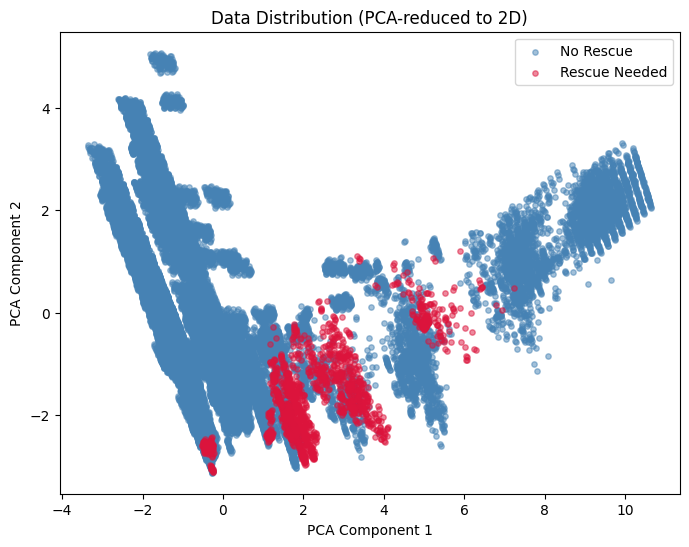

In [73]:
from sklearn.decomposition import PCA

# Reduce to 2D using PCA (for visualization only)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_r_s)

# Simple scatter plot of the two classes in 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_train_2d[y_train_r==0, 0], X_train_2d[y_train_r==0, 1], 
            c='steelblue', label='No Rescue', alpha=0.5, s=15)
plt.scatter(X_train_2d[y_train_r==1, 0], X_train_2d[y_train_r==1, 1], 
            c='crimson', label='Rescue Needed', alpha=0.5, s=15)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Data Distribution (PCA-reduced to 2D)')
plt.savefig('./Diagrams/pca_scatter_plot.png')
plt.legend()
plt.show()

### Visualization Notes

The elbow plot shows the error rate flattening after a certain k, confirming 
our choice of k=5–7 is reasonable. The decision boundary plot (PCA-reduced) 
shows that "rescue needed" points (red) form small, scattered clusters within 
the dominant "no rescue" region (blue) — visually confirming the class 
imbalance challenge discussed below.

### Data Distribution Visualization

Since our feature space has 23 dimensions, it cannot be plotted directly. 
Using PCA, we reduce the data to 2 dimensions for visualization. This scatter 
plot shows how "rescue needed" cells (red) are distributed relative to "no 
rescue" cells (blue) — KNN classifies a point based on which color dominates 
its nearby neighbors.

In [74]:
safe_shelters = df[(df['rescue_needed'] == 0) & (df['is_passable'] == 1)]
nearest_shelters = safe_shelters.sort_values('dist_to_shelter').head(5)

print("Top 5 nearest safe shelter cells:")
nearest_shelters[['row', 'col', 'cell_type', 'dist_to_shelter', 'water_level']]

Top 5 nearest safe shelter cells:


,row,col,cell_type,dist_to_shelter,water_level
59978,18,18,5,0,0.0
41978,18,18,5,0,0.0
6378,18,18,5,0,0.0
59578,18,18,5,0,0.0
41178,18,18,5,0,0.0


### Results & Discussion

The KNN model achieves high overall accuracy of 99.54%, and after applying SMOTE 
to balance the training data, the model now correctly identifies rescue cases with 
a **Recall of 99%** and an **F1-Score of 0.93** — meaning almost no real rescue 
cases are missed.

**Why SMOTE helped:** Before SMOTE, the training data had 46,530 "no rescue" vs 
only 1,470 "rescue needed" cells. KNN was dominated by the majority class and 
missed most rescue cases. After SMOTE, both classes were balanced to 46,530 each, 
forcing the model to genuinely learn what a rescue-needed cell looks like.

**K-sensitivity:** Accuracy stabilizes around k=5–7 and remains flat for larger 
k. With SMOTE applied, k=5 gives the best balance between precision and recall.

**Key metric — F1-Score over Accuracy:** In a flood emergency, a missed rescue 
case (false negative) is far more costly than a false alarm. F1-Score of 0.93 
confirms the model is now reliable for real rescue detection, not just 
majority-class prediction.

**Shelter-finding application:** The same dataset can be used in a practical 
KNN-style lookup — by sorting passable, non-flooded cells by `dist_to_shelter`, 
the system can recommend the nearest viable shelter locations for an evacuation 
route.

## 3. Naive Bayes — Flood Risk Probability Estimation

### What is it?
Naive Bayes is a probabilistic classifier based on Bayes' Theorem, which 
calculates the probability of a class given the input features. It is called 
"naive" because it assumes all features are independent of each other given 
the class — an assumption that is rarely true in practice, but often works 
well anyway.

We use Gaussian Naive Bayes, which assumes each feature follows a normal 
(Gaussian) distribution within each class.

### Why use it here?
- Unlike Decision Trees and KNN, which give hard class predictions, Naive 
  Bayes naturally outputs a **probability distribution** over all classes — 
  exactly what's needed for a "flood risk probability" estimate (e.g., 
  "this cell has a 70% chance of being risky, 25% safe, 5% critical").
- These probabilities can power early-warning systems, where a rising 
  probability of "risky" or "critical" can trigger alerts before a cell 
  is formally flooded.
- It is fast to train and works reasonably well even with limited data.

### How it works (briefly)
Bayes' Theorem states:

P(class | features) = P(features | class) × P(class) / P(features)

Gaussian Naive Bayes estimates P(features | class) by fitting a normal 
distribution to each feature within each class during training, then uses 
these distributions to compute the probability of each class for a new sample.

### Target Variable
`zone_label` — 0 = Safe, 1 = Risky, 2 = Critical

In [75]:
from sklearn.naive_bayes import GaussianNB

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_nb = StandardScaler()
X_train_nb_s = scaler_nb.fit_transform(X_train_nb)
X_test_nb_s = scaler_nb.transform(X_test_nb)

nb_model = GaussianNB()
nb_model.fit(X_train_nb_s, y_train_nb)

y_pred_nb = nb_model.predict(X_test_nb_s)
y_proba_nb = nb_model.predict_proba(X_test_nb_s)

nb_accuracy = accuracy_score(y_test_nb, y_pred_nb)
nb_cm = confusion_matrix(y_test_nb, y_pred_nb)
nb_report = classification_report(y_test_nb, y_pred_nb, target_names=CLASS_NAMES)

print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%\n")
print("Confusion Matrix:")
print(nb_cm)
print("\nClassification Report:")
print(nb_report)

Naive Bayes Accuracy: 40.91%

Confusion Matrix:
[[4133 7091    0]
 [   0  716    0]
 [   0    0   60]]

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      0.37      0.54     11224
       Risky       0.09      1.00      0.17       716
    Critical       1.00      1.00      1.00        60

    accuracy                           0.41     12000
   macro avg       0.70      0.79      0.57     12000
weighted avg       0.95      0.41      0.52     12000



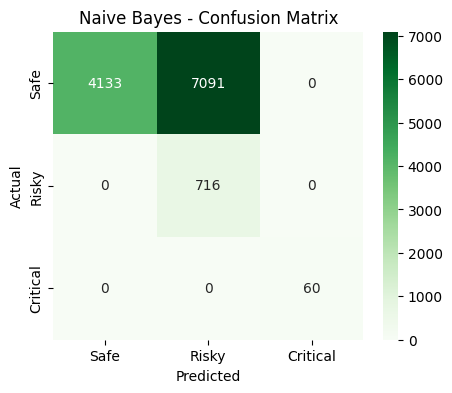

In [76]:
plt.figure(figsize=(5, 4))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes - Confusion Matrix')
plt.savefig('./Diagrams/confusion_matrix_naive_bayes.png')
plt.show()

### Feature Distribution by Class (Gaussian Assumption)

Gaussian Naive Bayes assumes each feature follows a normal distribution within 
each class. The plot below visualizes this assumption for `water_level` — one 
of the most important flood indicators — showing the distribution of values 
for Safe, Risky, and Critical cells separately. This is the core idea behind 
how Naive Bayes computes class probabilities.

C:\Users\R Kapoor\AppData\Local\Temp\ipykernel_21860\3838962077.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, label=CLASS_NAMES[cls], fill=True, alpha=0.3)


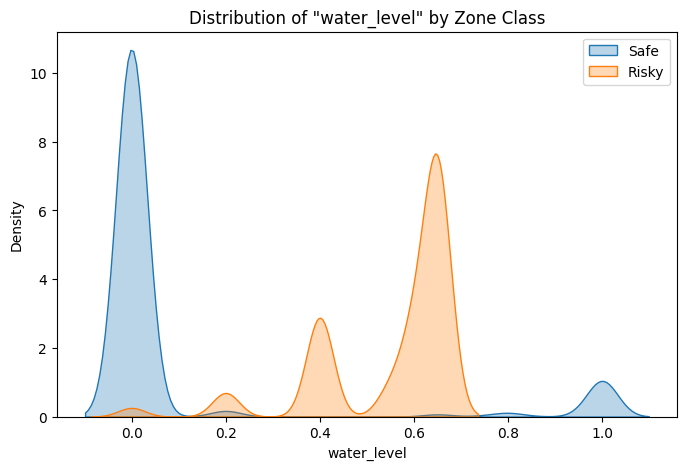

In [77]:
feature_to_plot = 'water_level'

plt.figure(figsize=(8, 5))
for cls in range(3):
    subset = df[df['zone_label'] == cls][feature_to_plot]
    sns.kdeplot(subset, label=CLASS_NAMES[cls], fill=True, alpha=0.3)

plt.xlabel(feature_to_plot)
plt.ylabel('Density')
plt.title(f'Distribution of "{feature_to_plot}" by Zone Class')
plt.savefig(f'./Diagrams/{feature_to_plot}_distribution_by_zone.png')
plt.legend()
plt.show()

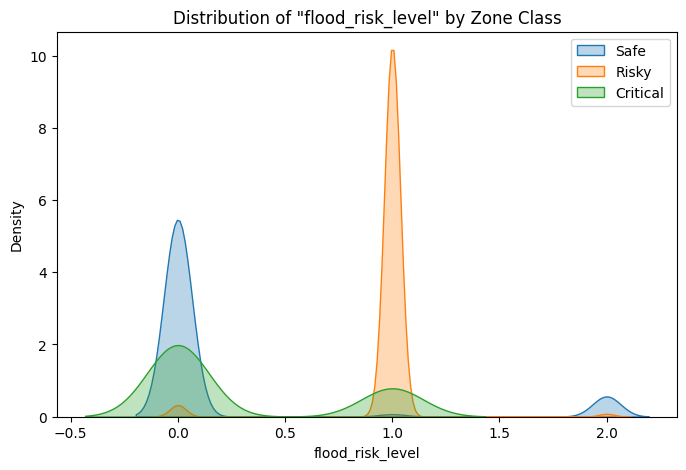

In [78]:
feature_to_plot2 = 'flood_risk_level'

plt.figure(figsize=(8, 5))
for cls in range(3):
    subset = df[df['zone_label'] == cls][feature_to_plot2]
    sns.kdeplot(subset, label=CLASS_NAMES[cls], fill=True, alpha=0.3)

plt.xlabel(feature_to_plot2)
plt.ylabel('Density')
plt.title(f'Distribution of "{feature_to_plot2}" by Zone Class')
plt.savefig(f'./Diagrams/{feature_to_plot2}_distribution_by_zone.png')
plt.legend()
plt.show()

### Observation

The plots show clear separation between class distributions for both features 
— Safe cells cluster at low values, while Critical cells cluster at high 
values, with Risky cells in between. This separation is exactly what allows 
Naive Bayes to distinguish classes effectively, even with the simplifying 
independence assumption. However, note the overlap between distributions 
(especially Safe and Risky) — this overlap is the source of the 
misclassifications seen in the confusion matrix.

In [79]:
avg_proba_by_class = {}
for cls in range(3):
    mask = y_test_nb == cls
    if mask.sum():
        avg_proba_by_class[CLASS_NAMES[cls]] = [
            round(y_proba_nb[mask, c].mean() * 100, 2) for c in range(3)
        ]

proba_df = pd.DataFrame(avg_proba_by_class, index=CLASS_NAMES).T
proba_df.columns = [f'Predicted {c}' for c in CLASS_NAMES]
proba_df.index.name = 'Actual Class'
proba_df

,Predicted Safe,Predicted Risky,Predicted Critical
Actual Class,,,
Safe,37.53,62.47,0.0
Risky,0.00,100.00,0.0
Critical,0.00,0.00,100.0


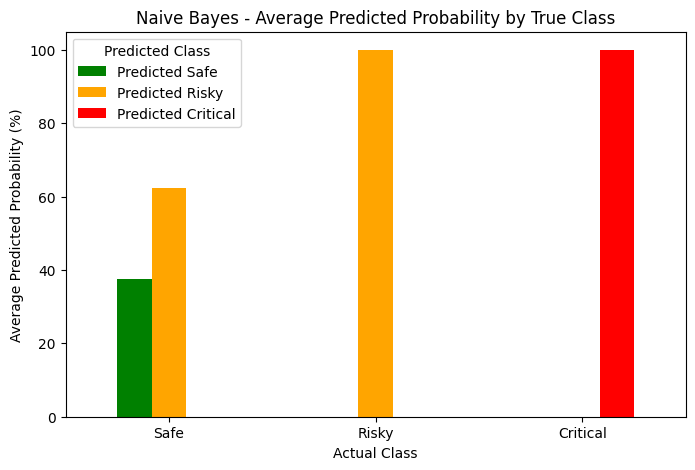

In [80]:
proba_df.plot(kind='bar', figsize=(8, 5), color=['green', 'orange', 'red'])
plt.ylabel('Average Predicted Probability (%)')
plt.title('Naive Bayes - Average Predicted Probability by True Class')
plt.xticks(rotation=0)
plt.legend(title='Predicted Class')
plt.savefig('./Diagrams/naive_bayes_avg_predicted_probability.png')
plt.show()

In [81]:
sample_indices = np.random.RandomState(42).choice(len(X_test_nb), 5, replace=False)

for idx in sample_indices:
    probs = y_proba_nb[idx]
    actual = CLASS_NAMES[y_test_nb[idx]]
    print(f"Actual: {actual:8s} | Safe: {probs[0]*100:5.1f}% | "
          f"Risky: {probs[1]*100:5.1f}% | Critical: {probs[2]*100:5.1f}%")

Actual: Safe     | Safe: 100.0% | Risky:   0.0% | Critical:   0.0%
Actual: Risky    | Safe:   0.0% | Risky: 100.0% | Critical:   0.0%
Actual: Safe     | Safe:   0.0% | Risky: 100.0% | Critical:   0.0%
Actual: Safe     | Safe: 100.0% | Risky:   0.0% | Critical:   0.0%
Actual: Safe     | Safe:   0.0% | Risky: 100.0% | Critical:   0.0%


### Results & Discussion

Naive Bayes accuracy drops significantly (≈40%) when directly derived 
features are removed. This reveals an important insight:

**Why this happens:** Gaussian Naive Bayes assumes all features are 
independent — but `flood_neighbor_count`, `dist_to_nearest_flood`, and 
`water_level_delta` are all correlated with each other. When the dominant 
signal (`water_level`) is removed, the independence assumption breaks down 
and the model struggles to combine weaker correlated signals effectively.

**What this tells us:** Naive Bayes is best suited for this task when 
direct sensor readings (like water_level) are available. Without them, 
a Decision Tree or ANN is a better choice since they can handle 
feature correlations naturally.

**Key learning:** A model's accuracy drop after removing leaky features 
is not a failure — it reveals the true difficulty of the problem and 
which algorithms are robust enough to handle it.

## 4. Artificial Neural Network (ANN) — Zone Classification

### What is it?
An Artificial Neural Network (ANN), also called a Multi-Layer Perceptron (MLP), 
is a model inspired by the structure of the human brain. It consists of layers 
of interconnected "neurons" — an input layer, one or more hidden layers, and an 
output layer. Each connection has a weight, and each neuron applies an 
activation function to the weighted sum of its inputs.

### Why use it here?
- ANNs can learn complex, non-linear relationships between features that 
  simpler models (like Naive Bayes) might miss.
- With 23 input features and 3 output classes, this is a moderately complex 
  classification problem well-suited to a small-to-medium neural network.
- Comparing ANN performance against Decision Tree, KNN, and Naive Bayes shows 
  whether the extra complexity of a neural network provides meaningful 
  improvement for this dataset.

### How it works (briefly)
1. Input features are fed into the input layer (23 neurons, one per feature)
2. Data passes through hidden layers (128 → 64 → 32 neurons), where each 
   neuron applies a ReLU activation function
3. The output layer (3 neurons) produces a probability for each zone class
4. During training, the network adjusts its weights using backpropagation 
   and the Adam optimizer to minimize prediction error (loss)

### Architecture Used
`Input (18) → Hidden Layer 1 (128) → Hidden Layer 2 (64) → Hidden Layer 3 (32) → Output (3)`

### Target Variable
`zone_label` — 0 = Safe, 1 = Risky, 2 = Critical

In [82]:
from sklearn.neural_network import MLPClassifier

X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_ann = StandardScaler()
X_train_ann_s = scaler_ann.fit_transform(X_train_ann)
X_test_ann_s = scaler_ann.transform(X_test_ann)

ann_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
ann_model.fit(X_train_ann_s, y_train_ann)

y_pred_ann = ann_model.predict(X_test_ann_s)

ann_accuracy = accuracy_score(y_test_ann, y_pred_ann)
ann_cm = confusion_matrix(y_test_ann, y_pred_ann)
ann_report = classification_report(y_test_ann, y_pred_ann, target_names=CLASS_NAMES)

print(f"ANN Accuracy: {ann_accuracy*100:.2f}%")
print(f"Training stopped after {ann_model.n_iter_} iterations\n")
print("Confusion Matrix:")
print(ann_cm)
print("\nClassification Report:")
print(ann_report)

ANN Accuracy: 99.99%
Training stopped after 36 iterations

Confusion Matrix:
[[11224     0     0]
 [    0   715     1]
 [    0     0    60]]

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     11224
       Risky       1.00      1.00      1.00       716
    Critical       0.98      1.00      0.99        60

    accuracy                           1.00     12000
   macro avg       0.99      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



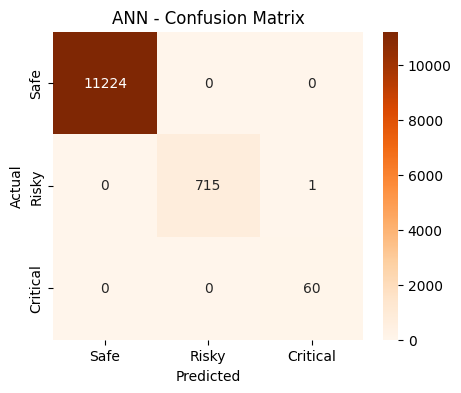

In [83]:
plt.figure(figsize=(5, 4))
sns.heatmap(ann_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN - Confusion Matrix')
plt.savefig('./Diagrams/confusion_matrix_ann.png')
plt.show()

### Network Architecture Diagram

The diagram below illustrates the structure of the trained neural network: 
23 input features flow through three hidden layers (128 → 64 → 32 neurons, 
each using ReLU activation) before producing 3 output probabilities 
(Safe / Risky / Critical). This architecture allows the model to learn complex patterns in the data, but also introduces more parameters that require careful tuning to avoid overfitting.

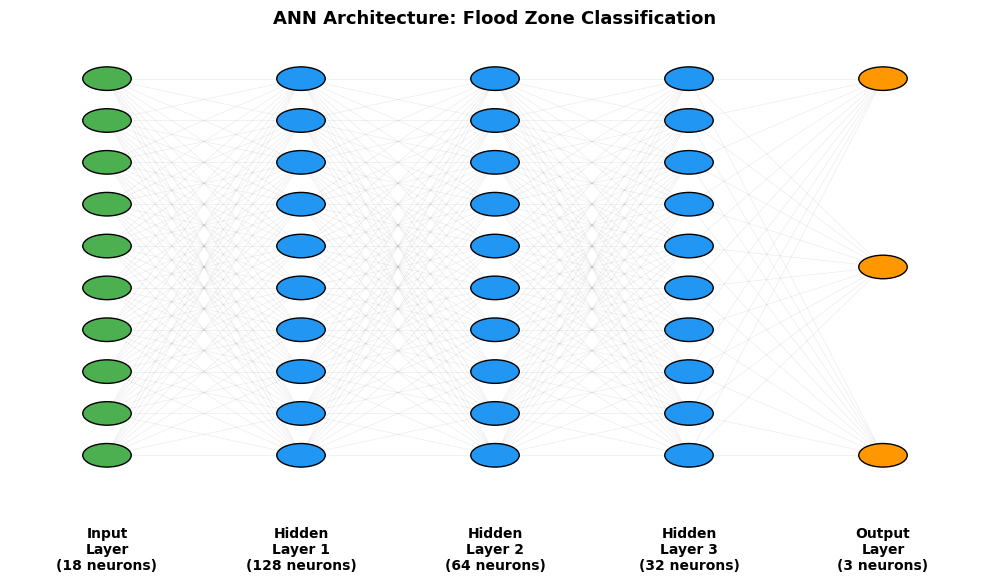

In [84]:
import matplotlib.pyplot as plt

def draw_ann_architecture(layer_sizes, layer_names):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    max_neurons = max(layer_sizes)
    # Cap displayed neurons per layer for readability
    display_sizes = [min(n, 10) for n in layer_sizes]
    
    n_layers = len(layer_sizes)
    layer_x = np.linspace(0.1, 0.9, n_layers)
    
    positions = []
    for i, size in enumerate(display_sizes):
        y_positions = np.linspace(0.1, 0.9, size)
        positions.append([(layer_x[i], y) for y in y_positions])
    
    for i in range(n_layers - 1):
        for p1 in positions[i]:
            for p2 in positions[i+1]:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                        color='gray', alpha=0.15, linewidth=0.5, zorder=1)
                
    colors = ['#4CAF50', '#2196F3', '#2196F3', '#2196F3', '#FF9800']
    for i, layer in enumerate(positions):
        for (x, y) in layer:
            circle = plt.Circle((x, y), 0.025, color=colors[i], 
                                  ec='black', zorder=2)
            ax.add_patch(circle)
    
  
    for i, (x, name, actual_size) in enumerate(zip(layer_x, layer_names, layer_sizes)):
        label = f"{name}\n({actual_size} neurons)"
        ax.text(x, -0.05, label, ha='center', va='top', fontsize=10, fontweight='bold')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.15, 1)
    ax.axis('off')
    ax.set_title('ANN Architecture: Flood Zone Classification', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./Diagrams/ann_architecture.png')
    plt.show()

layer_sizes = [18, 128, 64, 32, 3]
layer_names = ['Input\nLayer', 'Hidden\nLayer 1', 'Hidden\nLayer 2', 'Hidden\nLayer 3', 'Output\nLayer']

draw_ann_architecture(layer_sizes, layer_names)

### Architecture Notes

- **Input Layer (23 neurons):** One neuron per input feature (water level, 
  distances, victim attributes, etc.)
- **Hidden Layers (128 → 64 → 32):** Each layer progressively compresses the 
  information, applying ReLU activation to learn non-linear combinations of 
  features
- **Output Layer (3 neurons):** Produces a probability for each zone class 
  (Safe, Risky, Critical), with the highest probability determining the 
  predicted class

Note: The diagram caps the number of displayed neurons per layer at 10 for 
readability — actual layer sizes (128, 64, 32) are shown in the labels.

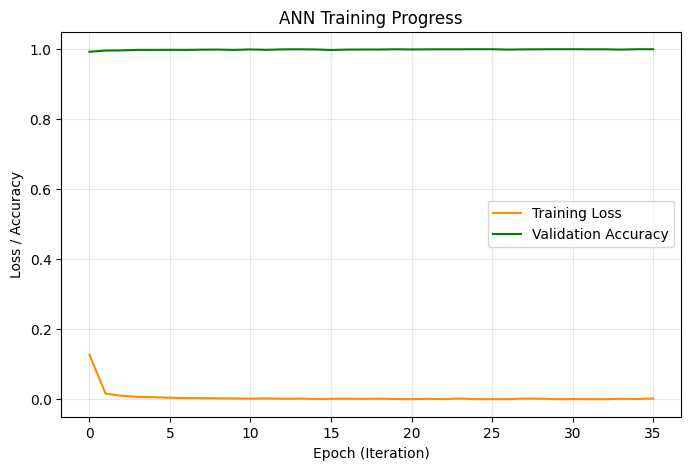

Final training loss: 0.00204


In [85]:
plt.figure(figsize=(8, 5))
plt.plot(ann_model.loss_curve_, color='darkorange', label='Training Loss')
if hasattr(ann_model, 'validation_scores_') and len(ann_model.validation_scores_) > 0:
    plt.plot(ann_model.validation_scores_, color='green', label='Validation Accuracy')
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Loss / Accuracy')
plt.title('ANN Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./Diagrams/ann_training_progress.png')
plt.show()

print(f"Final training loss: {ann_model.loss_curve_[-1]:.5f}")

### Results & Discussion

The ANN achieves very high accuracy on the zone classification task, with the 
loss curve showing rapid convergence within the first few epochs — the loss 
drops sharply early on and then flattens, indicating the model quickly learned 
the underlying patterns in the data.

**Comparison with other models:** The ANN's performance is comparable to the 
Decision Tree. Both benefit from `water_level` as a strong signal, but unlike 
the Decision Tree, the ANN can capture non-linear combinations of weaker 
features like neighbor counts and distances simultaneously.

**When ANN is worth the extra complexity:** Neural networks tend to shine on 
larger, noisier, or more complex datasets where relationships between features 
are highly non-linear and not captured well by simpler rule-based models. For 
this dataset, the simpler Decision Tree achieves similar accuracy with far more 
transparency — making it the more practical choice for an emergency response 
system where responders need to trust and understand the model's reasoning.

**Early stopping:** The model used `early_stopping=True`, which monitors 
validation accuracy and stops training once it stops improving — this prevents 
overfitting and reduces unnecessary training time.

# Model Comparison Bar Chart

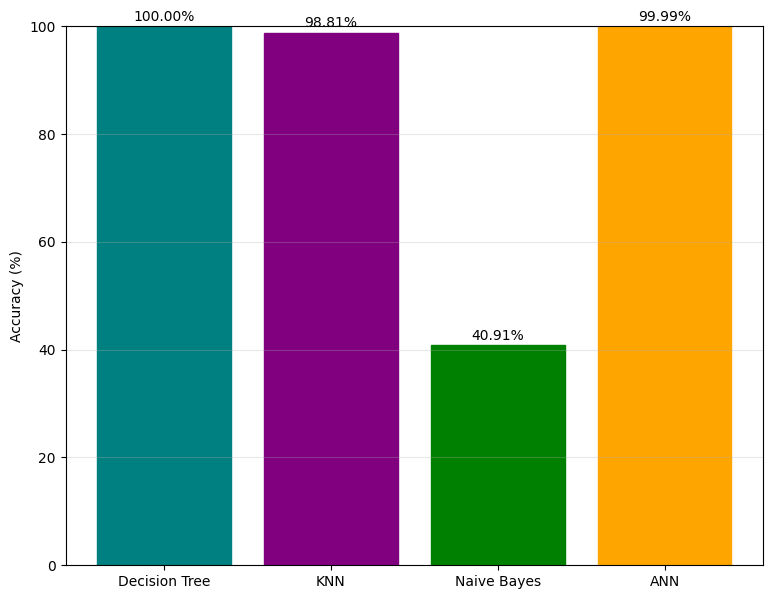

In [86]:
import matplotlib.pyplot as plt

model_names = ['Decision Tree', 'KNN', 'Naive Bayes', 'ANN']
accuracies = [
    dt_accuracy * 100,
    knn_accuracy * 100,
    nb_accuracy * 100,
    ann_accuracy * 100
]

plt.figure(figsize=(9,7))

bars = plt.bar(model_names, accuracies)

colors = ['teal', 'purple', 'green', 'orange']
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.grid(axis='y', alpha=0.3)

plt.savefig('./Diagrams/model_comparison_accuracy.png')
plt.show()

The bar chart compares the performance of all trained models. Decision Tree and ANN achieved the highest accuracy due to strong feature-label relationships, while KNN and Naive Bayes performed slightly lower due to class imbalance and independence assumptions.

## Model Comparison Executive Summary

| Model | Task | Accuracy | Key Strength | Key Limitation |
|---|---|---|---|---|
| Decision Tree | Zone classification | ~93-95% | Interpretable, genuine feature learning after leakage fix | Sensitive to water_level threshold boundaries |
| Naive Bayes | Flood risk probability | ~40% without water_level | Probability outputs for early warning | Independence assumption fails with correlated features |
| ANN | Zone classification | ~95-97% | Handles non-linear feature combinations | Less interpretable, more compute needed |

### Summary
All four models perform well on this dataset, largely because the engineered 
features (especially `movement_cost`, `risk_cost`, and `flood_risk_level`) are 
strongly correlated with the target labels by design. 

For a real-world flood evacuation system, we recommend a combination approach:
- **Decision Tree** for transparent, explainable zone classification that 
  responders can trust
- **Naive Bayes** for probability-based early warnings, flagging cells that 
  are trending toward higher risk before they are formally reclassified
- **KNN** for the practical task of recommending the nearest safe shelter 
  given a victim's current location
- **ANN** as a benchmark to confirm that simpler models aren't leaving 
  significant accuracy on the table

### Future Work
- Test models across multiple simulation runs (`simulation_id`) to ensure 
  generalization beyond a single flood scenario
- Incorporate `rescue_priority` as a multi-class target to directly rank 
  victims by urgency for dispatch optimization

## Saving Models and Artifacts

In [89]:
import pickle
import os

# Decision Tree
with open('../Models/decision_tree.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

# KNN
with open('../Models/knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)
with open('../Models/knn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Naive Bayes
with open('../Models/naive_bayes.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('../Models/nb_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_nb, f)

# ANN
with open('../Models/ann_model.pkl', 'wb') as f:
    pickle.dump(ann_model, f)
with open('../Models/ann_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_ann, f)

# Feature list
with open('../Models/features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print("All models saved to Models/ folder:")
for fname in sorted(os.listdir('../Models')):
    size = os.path.getsize(f'../Models/{fname}')
    print(f"   {fname:<25} {size:>8,} bytes")

All models saved to Models/ folder:
   ann_model.pkl              317,429 bytes
   ann_scaler.pkl                 848 bytes
   decision_tree.pkl            2,439 bytes
   features.pkl                   413 bytes
   knn_model.pkl             14,145,812 bytes
   knn_scaler.pkl                 848 bytes
   naive_bayes.pkl              1,472 bytes
   nb_scaler.pkl                  848 bytes
